In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("store_sales.csv")

df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   object 
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 285.3+ KB


In [4]:
df.describe()

,store,sales,promo,holiday
count,7300.000000,7300.000000,7300.000000,7300.000000
mean,5.500000,228.434571,0.202192,0.104110
std,2.872478,26.625636,0.401662,0.305424
min,1.000000,160.710000,0.000000,0.000000
25%,3.000000,209.217500,0.000000,0.000000
50%,5.500000,226.795000,0.000000,0.000000
75%,8.000000,245.590000,0.000000,0.000000
max,10.000000,340.730000,1.000000,1.000000


In [5]:
df.isnull().sum()

,0
date,0
store,0
sales,0
promo,0
holiday,0


In [6]:
print(df.columns)

Index(['date', 'store', 'sales', 'promo', 'holiday'], dtype='object')


In [10]:
df['date'] = pd.to_datetime(df['date'])

In [12]:
df['Day_Number'] = (df['date'] - df['date'].min()).dt.days

In [16]:
X = df[['Day_Number']]
y = df['sales']

In [17]:
model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [18]:
predictions = model.predict(X)

print(predictions[:10])

[210.75834265 210.80683711 210.85533156 210.90382602 210.95232047
 211.00081492 211.04930938 211.09780383 211.14629829 211.19479274]


In [19]:
mae = mean_absolute_error(y, predictions)

r2 = r2_score(y, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 19.673779889856586
R2 Score: 0.14733547406733372


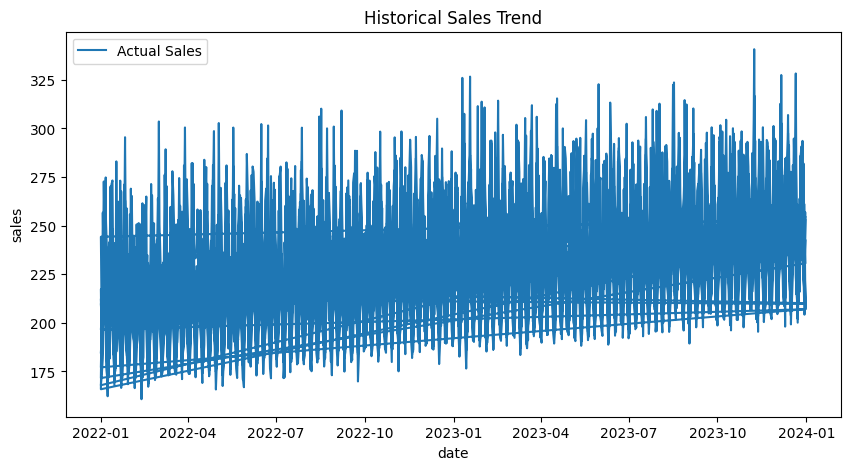

In [21]:
plt.figure(figsize=(10,5))

plt.plot(df['date'],
         y,
         label='Actual Sales')

plt.title("Historical Sales Trend")

plt.xlabel("date")
plt.ylabel("sales")

plt.legend()

plt.show()

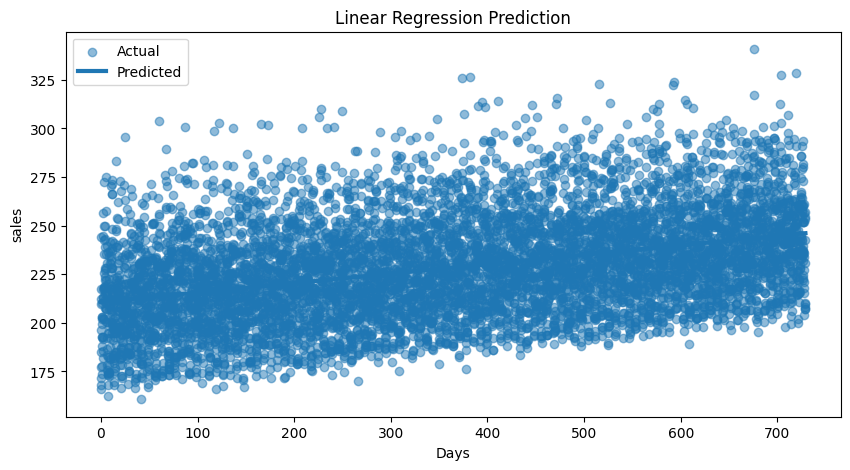

In [22]:
plt.figure(figsize=(10,5))

plt.scatter(
    df['Day_Number'],
    y,
    alpha=0.5,
    label='Actual'
)

plt.plot(
    df['Day_Number'],
    predictions,
    linewidth=3,
    label='Predicted'
)

plt.title("Linear Regression Prediction")

plt.xlabel("Days")
plt.ylabel("sales")

plt.legend()

plt.show()

In [23]:
future_days = np.arange(
    df['Day_Number'].max()+1,
    df['Day_Number'].max()+31
).reshape(-1,1)

future_predictions = model.predict(future_days)

future_predictions[:10]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([246.15929427, 246.20778872, 246.25628318, 246.30477763,
       246.35327208, 246.40176654, 246.45026099, 246.49875545,
       246.5472499 , 246.59574436])

In [25]:
future_dates = pd.date_range(
    start=df['date'].max()+pd.Timedelta(days=1),
    periods=30
)

forecast_df = pd.DataFrame({
    'date': future_dates,
    'Forecast_Sales': future_predictions
})

forecast_df.head()

,date,Forecast_Sales
0,2024-01-01,246.159294
1,2024-01-02,246.207789
2,2024-01-03,246.256283
3,2024-01-04,246.304778
4,2024-01-05,246.353272


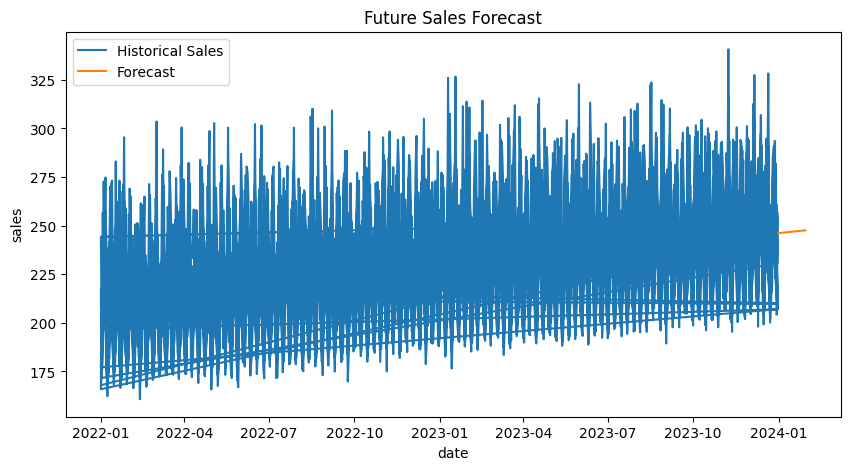

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    df['date'],
    y,
    label='Historical Sales'
)

plt.plot(
    forecast_df['date'],
    forecast_df['Forecast_Sales'],
    label='Forecast'
)

plt.title("Future Sales Forecast")

plt.xlabel("date")
plt.ylabel("sales")

plt.legend()

plt.show()